In [2]:
from POSEIDON.core import create_star
from POSEIDON.constants import R_Sun
from POSEIDON.stellar import stellar_contamination
import numpy as np
import matplotlib.pyplot as plt
import itertools



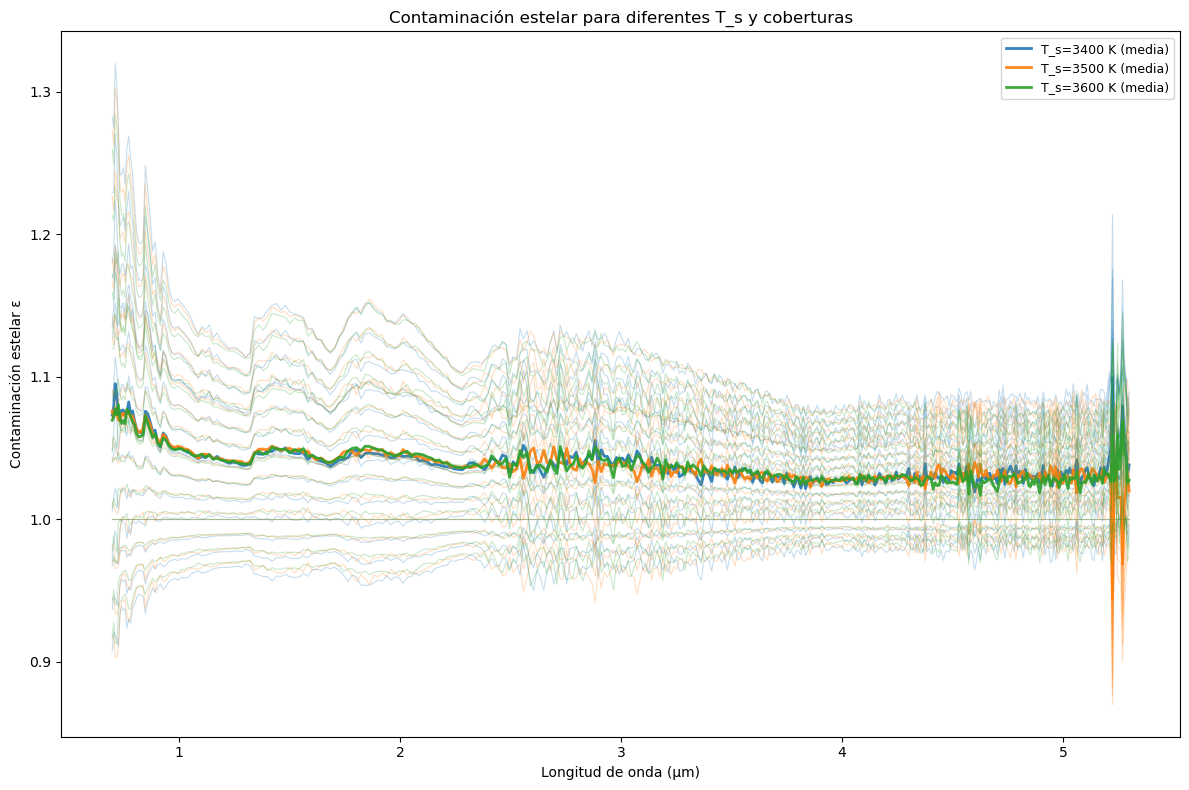

In [4]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor
from collections import defaultdict

# ==================== Parámetros globales ====================
R_s     = 0.468 * R_Sun
M_s     = 0.495
log_g_s = 4.6
Met_s   = 0.0

T_s_values = np.array([3400.0, 3500.0, 3600.0])

# Cargar longitudes de onda (global para los workers)
wl = np.loadtxt("waves.txt")

# Fracciones de cobertura (5 valores incluyendo 0 y el extremo)
f_spot_values = np.linspace(0.0, 0.3, 4)   # 0.00, 0.075, 0.15, 0.225, 0.30
f_fac_values  = np.linspace(0.0, 0.4, 4)   # 0.00, 0.10, 0.20, 0.30, 0.40


# ==================== Worker para paralelizar ====================
def compute_epsilon_for_case(args):
    """
    Worker que se ejecuta en paralelo.

    args = (T_s, f_spot, f_fac)
    Devuelve: (T_s, f_spot, f_fac, epsilon)
    """
    T_s, f_spot, f_fac = args

    # Temperaturas de manchas y fáculas (modo Rackham)
    T_spot = 0.86 * T_s
    T_fac  = T_s + 100.0

    star = create_star(
        R_s, T_s, log_g_s, Met_s,
        stellar_grid="phoenix",
        stellar_contam="two_spots",
        f_spot=f_spot, T_spot=T_spot,
        f_fac=f_fac, T_fac=T_fac,
    )

    epsilon = stellar_contamination(star, wl)

    return T_s, f_spot, f_fac, epsilon


# ==================== Main ====================
if __name__ == "__main__":
    # 1) Construimos todas las tareas (T_s, f_spot, f_fac)
    tasks = []
    for T_s in T_s_values:
        for f_spot, f_fac in itertools.product(f_spot_values, f_fac_values):
            # Si quieres evitar coberturas ultra-extremas, puedes poner:
            # if f_spot + f_fac > 0.9:
            #     continue
            tasks.append((T_s, f_spot, f_fac))

    # 2) Ejecutamos en paralelo
    results = []
    with ProcessPoolExecutor() as ex:
        for res in ex.map(compute_epsilon_for_case, tasks):
            results.append(res)

    # 3) Reagrupamos resultados por T_s
    by_Ts = defaultdict(list)
    for T_s, f_spot, f_fac, epsilon in results:
        by_Ts[T_s].append((f_spot, f_fac, epsilon))

    # 4) Guardar archivos y hacer UN solo plot con 3 colores
    # Colores para cada temperatura
    color_map = {
        3400.0: "tab:blue",
        3500.0: "tab:orange",
        3600.0: "tab:green",
    }

    plt.figure(figsize=(12, 8))

    for T_s in sorted(T_s_values):
        epsilons = []
        color = color_map[T_s]

        for f_spot, f_fac, epsilon in by_Ts[T_s]:
            epsilons.append(epsilon)

            # Guardar archivo
            filename = (
                f"TLS/epsilon_T{int(T_s)}_"
                f"fspot{f_spot:.3f}_ffac{f_fac:.3f}.txt"
            )
            np.savetxt(filename, np.column_stack((wl, epsilon)))

            # Curvas individuales: finas y transparentosas
            plt.plot(
                wl, epsilon,
                color=color,
                alpha=0.25,
                linewidth=0.8
            )

        # Línea media por cada T_s (para la leyenda)
        epsilons = np.array(epsilons)
        epsilon_mean = epsilons.mean(axis=0)

        plt.plot(
            wl, epsilon_mean,
            color=color,
            alpha=0.9,
            linewidth=2.0,
            label=f"T_s={int(T_s)} K (media)"
        )

    plt.xlabel("Longitud de onda (μm)")
    plt.ylabel("Contaminación estelar ε")
    plt.title("Contaminación estelar para diferentes T_s y coberturas")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("epsilon_all_Ts.png", dpi=150)
    plt.show()
